## Adım 0: Veri Setinin Genel İncelenmesi ve Yorumlanması

**PCB Defects Veri Seti Hakkında Genel Değerlendirme:**

Bu veri seti, elektronik üretiminde kalite kontrol sürecinin klasik bir "nesne tespiti"
(object detection) problemi olarak modellenmesine uygun bir yapıya sahiptir.

1. **Veri seti küçük-orta ölçekli** (693 görsel, ~2950 hata örneği/bounding box). Bu,
   sıfırdan büyük bir model eğitmek için yeterli değil ancak **transfer learning**
   (önceden COCO gibi büyük bir veri setinde eğitilmiş bir modeli, örneğin YOLOv8'i,
   kendi verimizle ince ayar/fine-tune yapmak) için gayet uygundur.

2. **Sınıflar dengeli dağılmış** (her sınıfta yaklaşık 480–500 hata örneği). Bu,
   ekstra bir sınıf dengeleme tekniğine (oversampling vb.) ihtiyaç duymadan model
   eğitimine geçilebileceği anlamına gelir.

3. **Görsel çözünürlükleri yüksek** (örneğin 3034x1586 piksel) ancak hata bölgeleri
   (bounding box'lar) görece küçük alanlar kaplamaktadır (örn. 73x67 piksel). Bu,
   modelin "küçük nesne tespiti" konusunda zorlanabileceğini işaret etmektedir;
   özellikle Spur ve Mouse Bite gibi ince detaylı hatalarda dikkatli olunmalıdır.

4. **Gerçek üretim senaryosuna uygun**: Görseller, PCB kartlarının farklı
   bölgelerinden alınmış çekimlerden oluşmaktadır ve bir üretim hattı kamerasının
   gerçekte görebileceği türden görüntülere benzemektedir.

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_139e3d802e2041fa33549018d091ad3c'
!pip install kaggle
!kaggle datasets download -d akhatova/pcb-defects
!unzip -q -o pcb-defects.zip -d pcb_defects

Dataset URL: https://www.kaggle.com/datasets/akhatova/pcb-defects
License(s): unknown
pcb-defects.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!ls pcb_defects/PCB_DATASET



Annotations  images  PCB_USED  rotate.py  rotation


In [ ]:
!ls pcb_defects/PCB_DATASET/Annotations


Missing_hole  Mouse_bite  Open_circuit	Short  Spur  Spurious_copper


In [ ]:
!ls pcb_defects/PCB_DATASET/images


Missing_hole  Mouse_bite  Open_circuit	Short  Spur  Spurious_copper


In [ ]:
import os

base_path = "pcb_defects/PCB_DATASET/images"
classes = os.listdir(base_path)

for c in classes:
    count = len(os.listdir(os.path.join(base_path, c)))
    print(f"{c}: {count} görsel")

Spurious_copper: 116 görsel
Mouse_bite: 115 görsel
Short: 116 görsel
Open_circuit: 116 görsel
Missing_hole: 115 görsel
Spur: 115 görsel


In [ ]:
# Bir örnek görselin dosya adına bakalım (Missing_hole klasöründen)
import os

sample_folder = "pcb_defects/PCB_DATASET/images/Missing_hole"
sample_files = os.listdir(sample_folder)
print(sample_files[:5])  # ilk 5 dosya adını göster

['01_missing_hole_15.jpg', '12_missing_hole_10.jpg', '05_missing_hole_02.jpg', '01_missing_hole_16.jpg', '06_missing_hole_08.jpg']


In [ ]:
# Aynı isimli etiket (annotation) dosyasına bakalım
sample_annotation_folder = "pcb_defects/PCB_DATASET/Annotations/Missing_hole"
sample_annotations = os.listdir(sample_annotation_folder)
print(sample_annotations[:5])

['01_missing_hole_15.xml', '04_missing_hole_11.xml', '06_missing_hole_10.xml', '10_missing_hole_03.xml', '04_missing_hole_19.xml']


In [ ]:
# Bir örnek XML dosyasının içeriğini okuyup ekrana yazdıralım
with open("pcb_defects/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_11.xml", "r") as f:
    content = f.read()
print(content)

<annotation>
	<folder>Missing_hole</folder>
	<filename>01_missing_hole_11.jpg</filename>
	<path>/home/weapon/Desktop/PCB_DATASET/Missing_hole/01_missing_hole_11.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>3034</width>
		<height>1586</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>2073</xmin>
			<ymin>685</ymin>
			<xmax>2146</xmax>
			<ymax>752</ymax>
		</bndbox>
	</object>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1500</xmin>
			<ymin>736</ymin>
			<xmax>1559</xmax>
			<ymax>800</ymax>
		</bndbox>
	</object>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>482</xmin>
			<ymin>843</ymin>
			<xmax>562</xmax>
			<ymax

In [ ]:
import xml.etree.ElementTree as ET

# Tüm XML dosyalarını gezip toplam kutu (hata) sayısını sınıf bazında sayalım
annotation_base = "pcb_defects/PCB_DATASET/Annotations"
classes = os.listdir(annotation_base)

for c in classes:
    class_folder = os.path.join(annotation_base, c)
    total_boxes = 0
    for xml_file in os.listdir(class_folder):
        tree = ET.parse(os.path.join(class_folder, xml_file))
        root = tree.getroot()
        total_boxes += len(root.findall("object"))
    print(f"{c}: {total_boxes} hata örneği (bounding box)")

Spurious_copper: 503 hata örneği (bounding box)
Mouse_bite: 492 hata örneği (bounding box)
Short: 491 hata örneği (bounding box)
Open_circuit: 482 hata örneği (bounding box)
Missing_hole: 497 hata örneği (bounding box)
Spur: 488 hata örneği (bounding box)


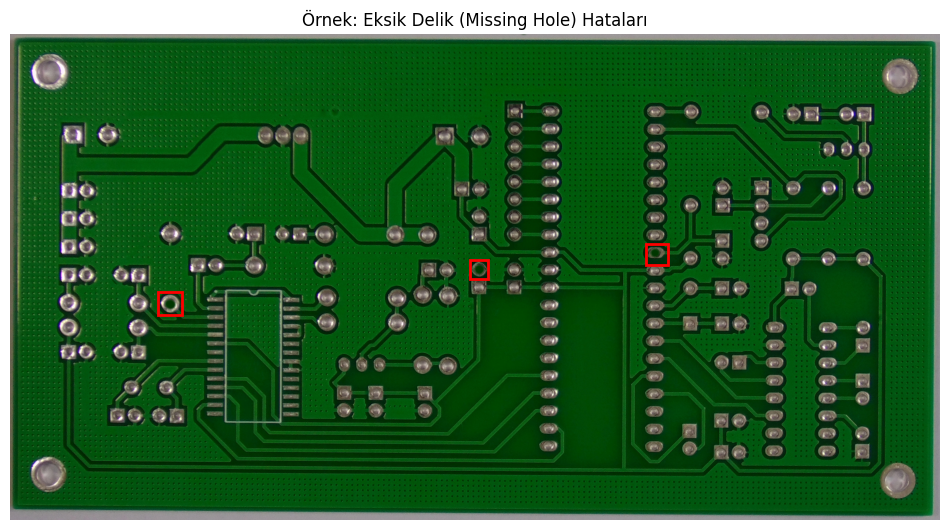

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import xml.etree.ElementTree as ET

# Örnek olarak bir "Missing_hole" (Eksik Delik) görselini açalım
img_path = "pcb_defects/PCB_DATASET/images/Missing_hole/01_missing_hole_11.jpg"
xml_path = "pcb_defects/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_11.xml"

# Görseli aç
img = Image.open(img_path)

# XML dosyasını oku, hata kutularının koordinatlarını al
tree = ET.parse(xml_path)
root = tree.getroot()

# Görseli çizdirmeye başla
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

# Her hata için kırmızı bir kutu çiz
for obj in root.findall("object"):
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    width = xmax - xmin
    height = ymax - ymin

    rect = patches.Rectangle((xmin, ymin), width, height,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.title("Örnek: Eksik Delik (Missing Hole) Hataları")
plt.axis('off')
plt.show()

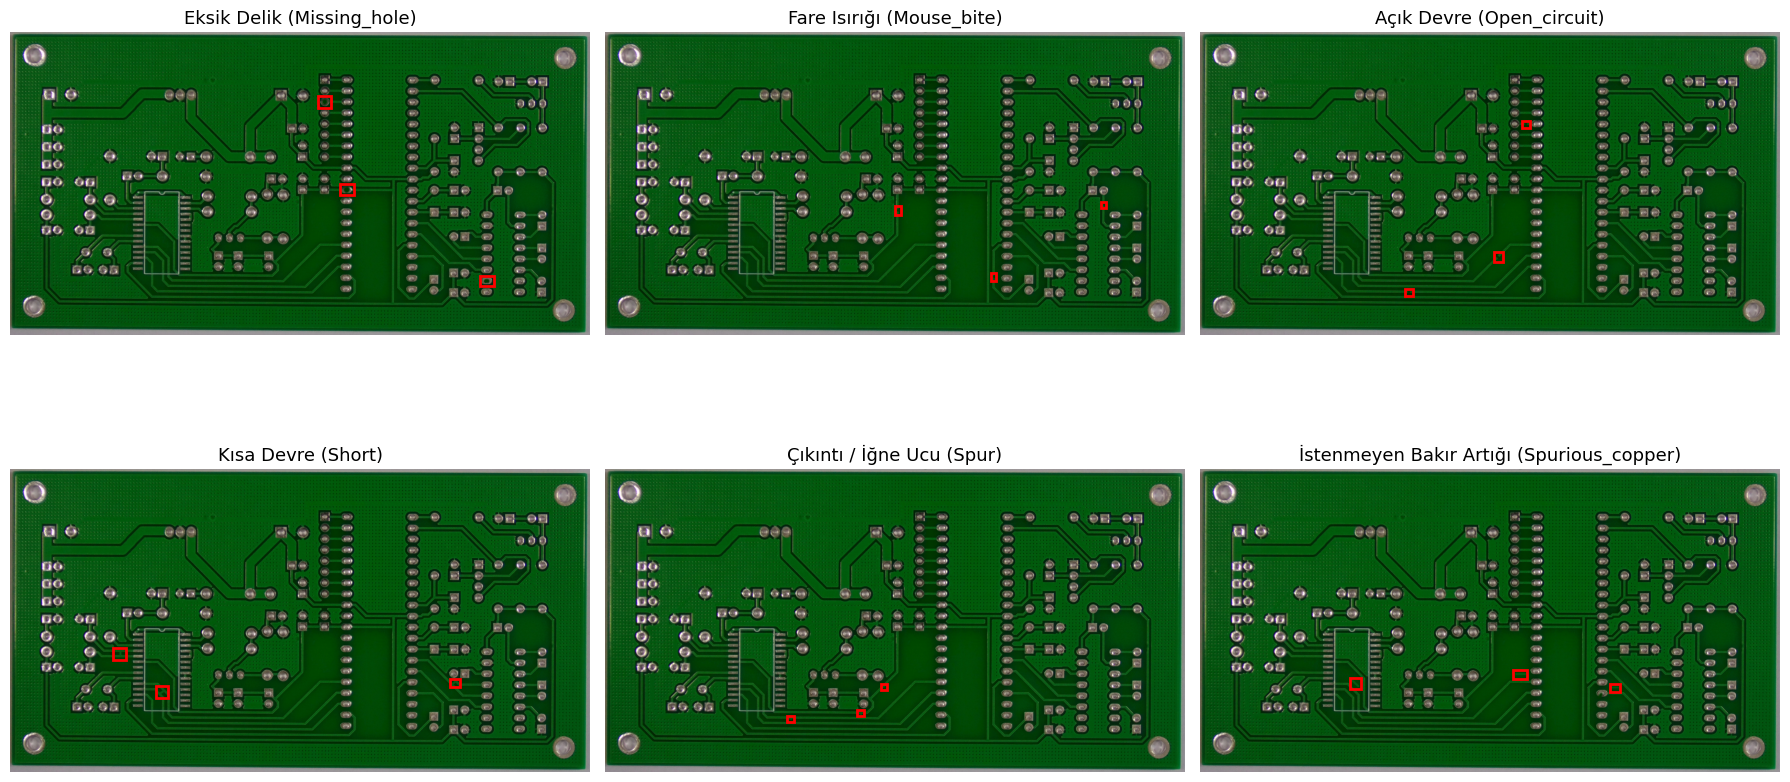

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import xml.etree.ElementTree as ET
import os

# 6 hata sınıfının Türkçe isimleri
class_names_tr = {
    "Missing_hole": "Eksik Delik",
    "Mouse_bite": "Fare Isırığı",
    "Open_circuit": "Açık Devre",
    "Short": "Kısa Devre",
    "Spur": "Çıkıntı / İğne Ucu",
    "Spurious_copper": "İstenmeyen Bakır Artığı"
}

images_base = "pcb_defects/PCB_DATASET/images"
annotations_base = "pcb_defects/PCB_DATASET/Annotations"

classes = sorted(os.listdir(images_base))

# 2 satır, 3 sütunluk bir grid oluştur
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, c in enumerate(classes):
    # Her sınıftan ilk görseli al
    img_folder = os.path.join(images_base, c)
    ann_folder = os.path.join(annotations_base, c)

    sample_file = sorted(os.listdir(img_folder))[0]
    sample_name = sample_file.replace(".jpg", "")

    img_path = os.path.join(img_folder, sample_file)
    xml_path = os.path.join(ann_folder, sample_name + ".xml")

    img = Image.open(img_path)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    ax = axes[idx]
    ax.imshow(img)

    # Hata kutularını çiz
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.set_title(f"{class_names_tr[c]} ({c})", fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import random
from PIL import Image
import xml.etree.ElementTree as ET

# Sınıf isimlerini YOLO formatı için numaralandıralım (0'dan başlar)
class_list = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]
class_to_id = {name: idx for idx, name in enumerate(class_list)}

# Kaynak klasörler
images_base = "pcb_defects/PCB_DATASET/images"
annotations_base = "pcb_defects/PCB_DATASET/Annotations"

# Hedef klasör yapısı (YOLO'nun beklediği düzen)
output_base = "dataset_yolo"
splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{output_base}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_base}/labels/{split}", exist_ok=True)

# XML'i YOLO formatına çeviren fonksiyon
def convert_xml_to_yolo(xml_path, img_width, img_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        # XML'deki bazı isimler küçük harfle yazılmış olabilir, eşleştirelim
        matched_class = None
        for c in class_list:
            if c.lower() == class_name.lower():
                matched_class = c
                break
        if matched_class is None:
            continue

        class_id = class_to_id[matched_class]

        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        # YOLO formatı: merkez_x, merkez_y, genişlik, yükseklik (hepsi 0-1 arası normalize)
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        w = (xmax - xmin) / img_width
        h = (ymax - ymin) / img_height

        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    return yolo_lines

# Tüm sınıflardaki görselleri toplayıp karıştıralım, sonra böleceğiz
all_samples = []
for c in class_list:
    img_folder = os.path.join(images_base, c)
    ann_folder = os.path.join(annotations_base, c)
    for fname in os.listdir(img_folder):
        name_no_ext = fname.replace(".jpg", "")
        img_path = os.path.join(img_folder, fname)
        xml_path = os.path.join(ann_folder, name_no_ext + ".xml")
        if os.path.exists(xml_path):
            all_samples.append((img_path, xml_path, name_no_ext))

random.seed(42)  # aynı sonucu tekrar üretebilmek için sabit tohum
random.shuffle(all_samples)

# %70 train, %15 val, %15 test olarak böl
n = len(all_samples)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_samples = all_samples[:train_end]
val_samples = all_samples[train_end:val_end]
test_samples = all_samples[val_end:]

split_map = {"train": train_samples, "val": val_samples, "test": test_samples}

# Her split için görselleri kopyala, etiketleri YOLO formatında oluştur
for split, samples in split_map.items():
    for img_path, xml_path, name in samples:
        img = Image.open(img_path)
        w, h = img.size

        # Görseli kopyala
        shutil.copy(img_path, f"{output_base}/images/{split}/{name}.jpg")

        # Etiketi YOLO formatına çevirip kaydet
        yolo_lines = convert_xml_to_yolo(xml_path, w, h)
        with open(f"{output_base}/labels/{split}/{name}.txt", "w") as f:
            f.write("\n".join(yolo_lines))

print(f"Toplam örnek: {n}")
print(f"Train: {len(train_samples)} görsel")
print(f"Val: {len(val_samples)} görsel")
print(f"Test: {len(test_samples)} görsel")

Toplam örnek: 693
Train: 485 görsel
Val: 104 görsel
Test: 104 görsel


In [ ]:
yaml_content = """train: /content/dataset_yolo/images/train
val: /content/dataset_yolo/images/val
test: /content/dataset_yolo/images/test

nc: 6
names: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml dosyası oluşturuldu.")
print(yaml_content)

data.yaml dosyası oluşturuldu.
train: /content/dataset_yolo/images/train
val: /content/dataset_yolo/images/val
test: /content/dataset_yolo/images/test

nc: 6
names: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']



In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Önceden eğitilmiş küçük bir YOLOv8 modelini temel alarak başlıyoruz (transfer learning)
model = YOLO("yolov8n.pt")  # "n" = nano, en küçük ve en hızlı versiyon, öğrenmeye başlamak için ideal

# Eğitimi başlat
results = model.train(
    data="data.yaml",
    epochs=50,          # veri setini 50 kez baştan sona görecek
    imgsz=640,           # görselleri 640x640 boyutuna getirerek işleyecek
    batch=16,             # her seferde 16 görsel işlenecek
    project="pcb_training",
    name="ilk_deneme"
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ilk_deneme-2, nbs=64, nms=False, opset=None, optimiz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

# Drive'da proje için bir klasör oluştur
drive_folder = "/content/drive/MyDrive/AOI_Vestel_Proje"
os.makedirs(drive_folder, exist_ok=True)

# En iyi modeli (best.pt) Drive'a kopyala
shutil.copy(
    "/content/runs/detect/pcb_training/ilk_deneme-2/weights/best.pt",
    f"{drive_folder}/best.pt"
)

print("best.pt başarıyla Drive'a kaydedildi!")
print(f"Konum: {drive_folder}/best.pt")

best.pt başarıyla Drive'a kaydedildi!
Konum: /content/drive/MyDrive/AOI_Vestel_Proje/best.pt


In [ ]:
from ultralytics import YOLO

# Eğitilmiş en iyi modeli yükle
model = YOLO("/content/runs/detect/pcb_training/ilk_deneme-2/weights/best.pt")

# Test verisiyle değerlendirme yap
test_results = model.val(data="data.yaml", split="test")

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2028.1±443.0 MB/s, size: 1340.7 KB)
val: Scanning /content/dataset_yolo/labels/test... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 1.2Kit/s 0.1s
val: New cache created: /content/dataset_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1s/it 7.7s
                   all        104        450      0.883      0.818      0.861      0.428
          Missing_hole         20         84      0.976      0.964       0.97      0.565
            Mouse_bite         18         73      0.836      0.629      0.708       0.33
          Open_circuit         18         71      0.752      0.746      0.848      0.366
                 Short         15         68      0.902      0.912      0.91

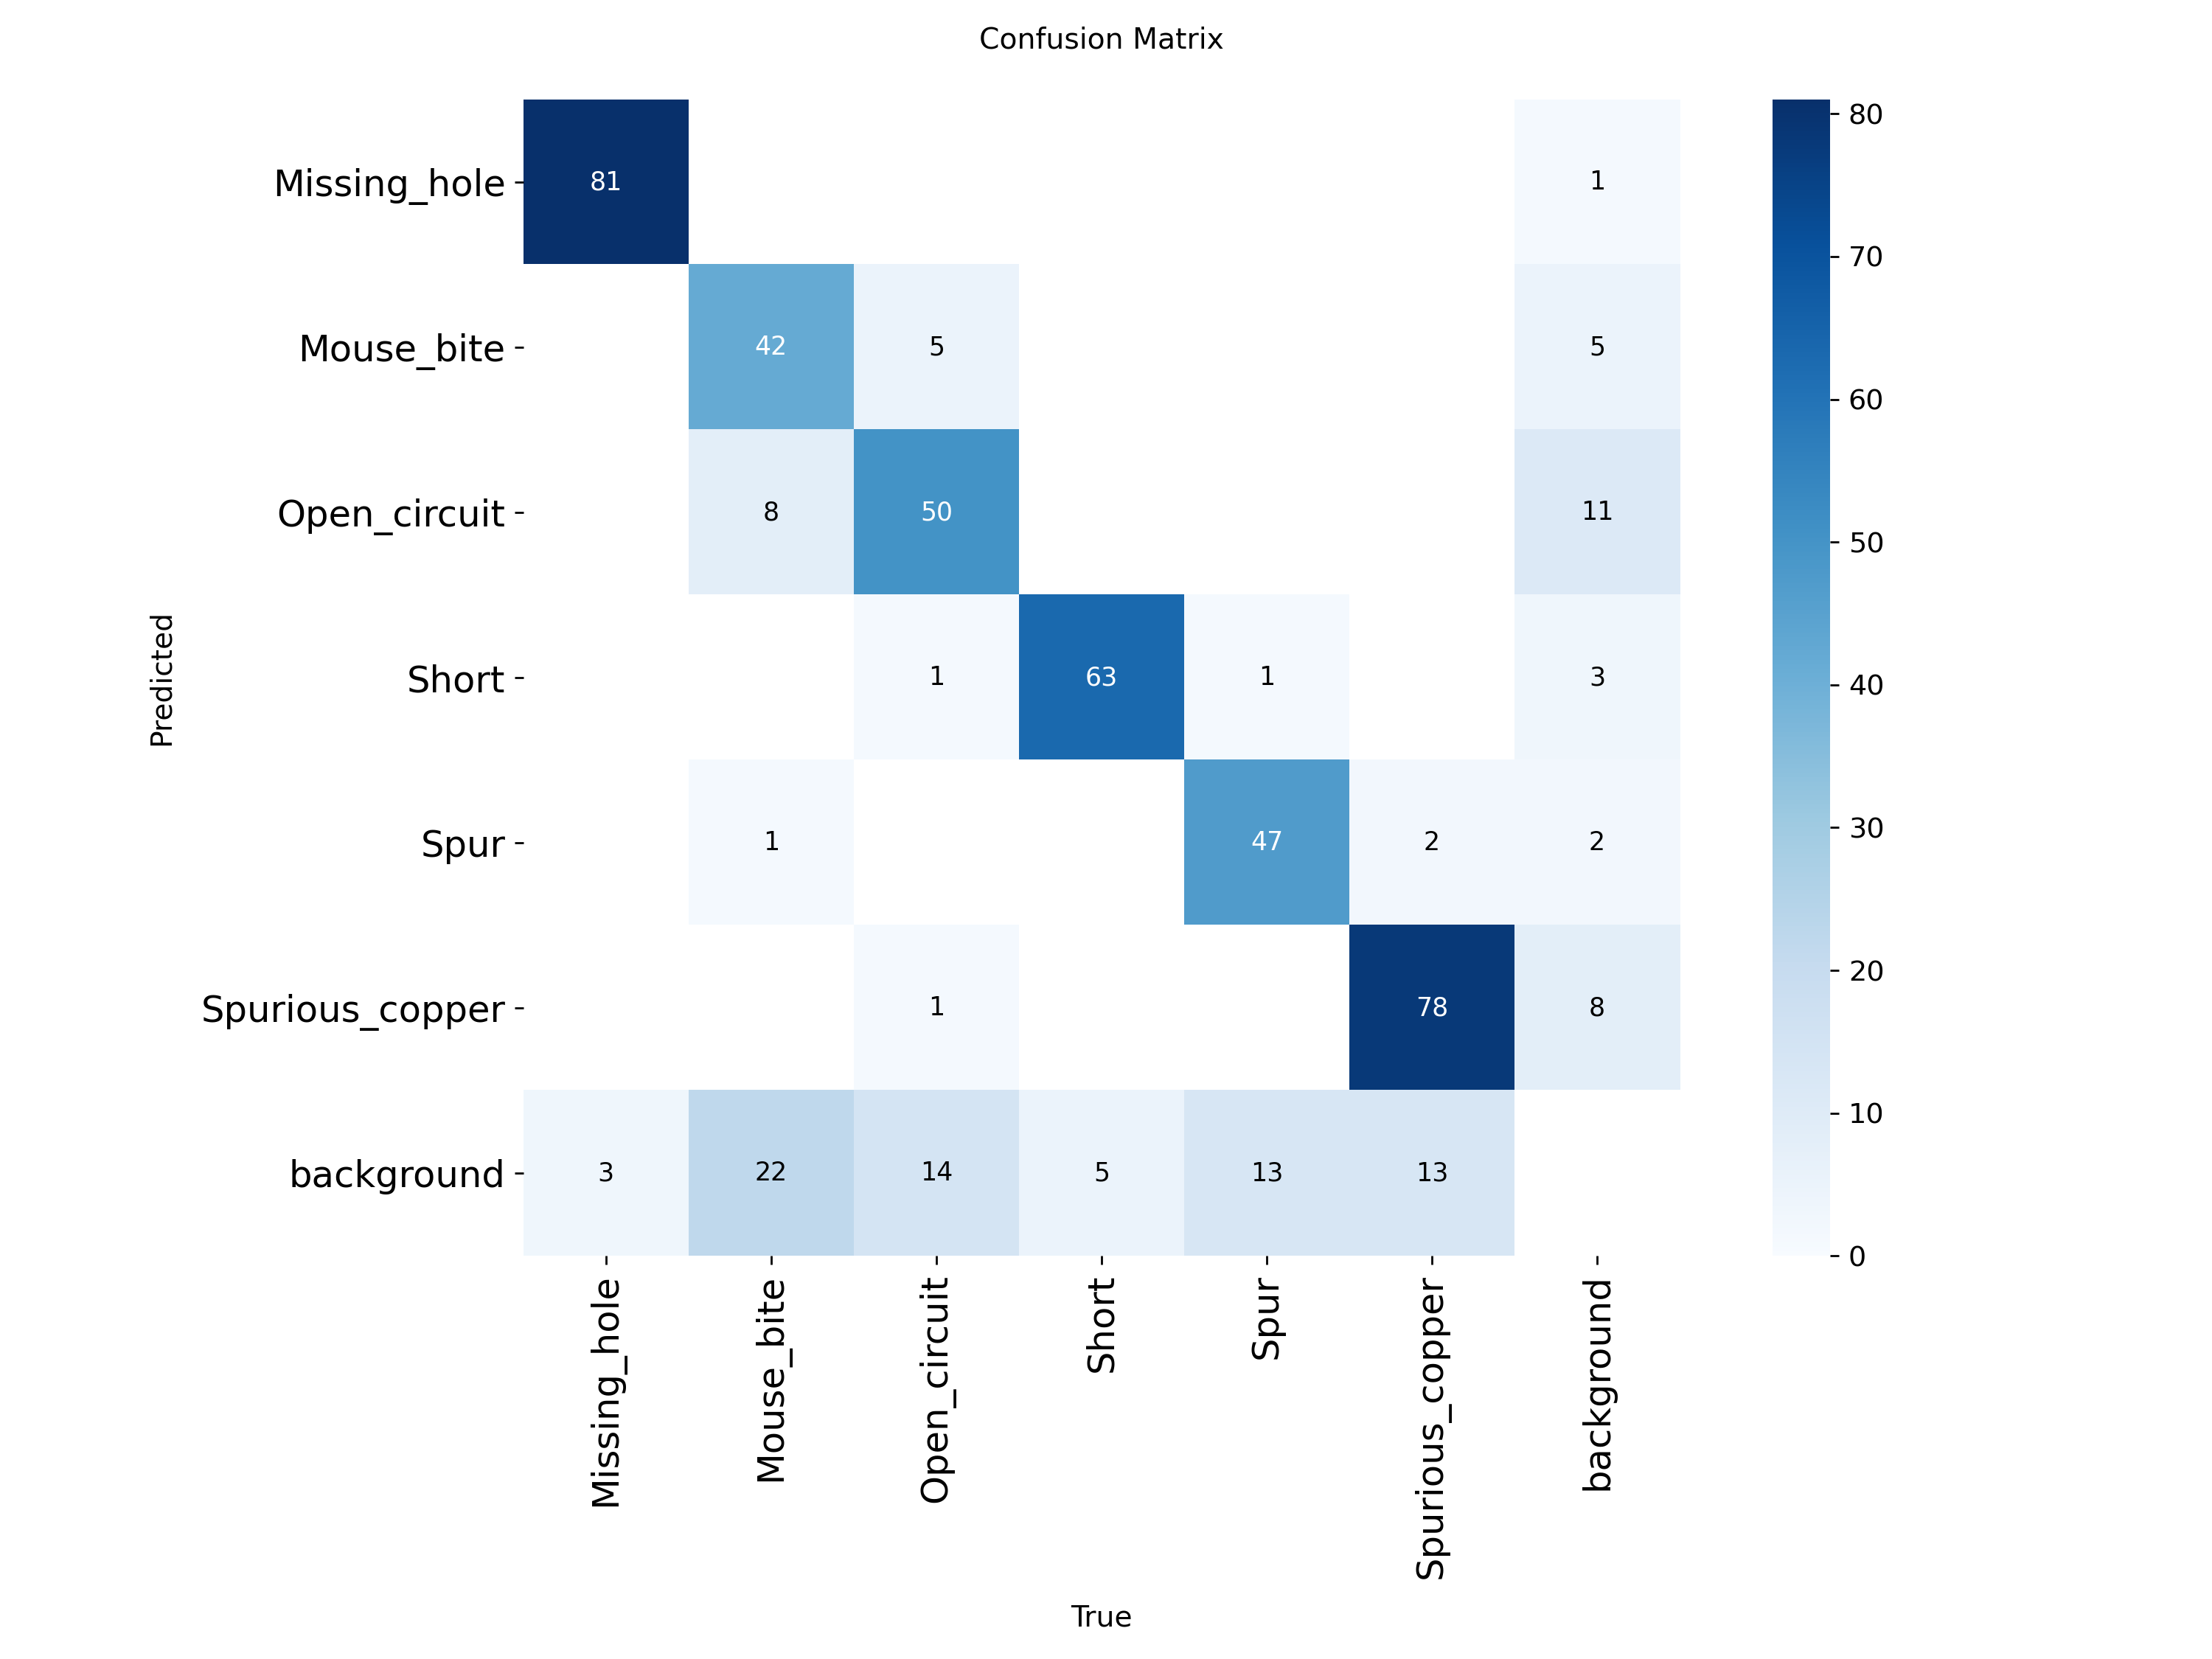

In [ ]:
from IPython.display import Image as IPImage, display

display(IPImage(filename="/content/runs/detect/val/confusion_matrix.png"))

In [ ]:
import time
from ultralytics import YOLO

model = YOLO("/content/runs/detect/pcb_training/ilk_deneme-2/weights/best.pt")

# Test setinden bir örnek görsel seçelim
test_img_path = "dataset_yolo/images/test"
import os
sample_img = os.path.join(test_img_path, os.listdir(test_img_path)[0])

# Isınma turu (ilk çalıştırma her zaman biraz yavaş olur, onu saymıyoruz)
_ = model(sample_img, verbose=False)

# 20 kez çalıştırıp ortalama süreyi ölçelim
n_runs = 20
start = time.time()
for _ in range(n_runs):
    results = model(sample_img, verbose=False)
end = time.time()

avg_time_ms = ((end - start) / n_runs) * 1000
fps = 1000 / avg_time_ms

print(f"Ortalama çıkarım (inference) süresi: {avg_time_ms:.2f} ms")
print(f"Saniyede işlenebilecek kart sayısı (FPS): {fps:.1f}")

Ortalama çıkarım (inference) süresi: 49.53 ms
Saniyede işlenebilecek kart sayısı (FPS): 20.2


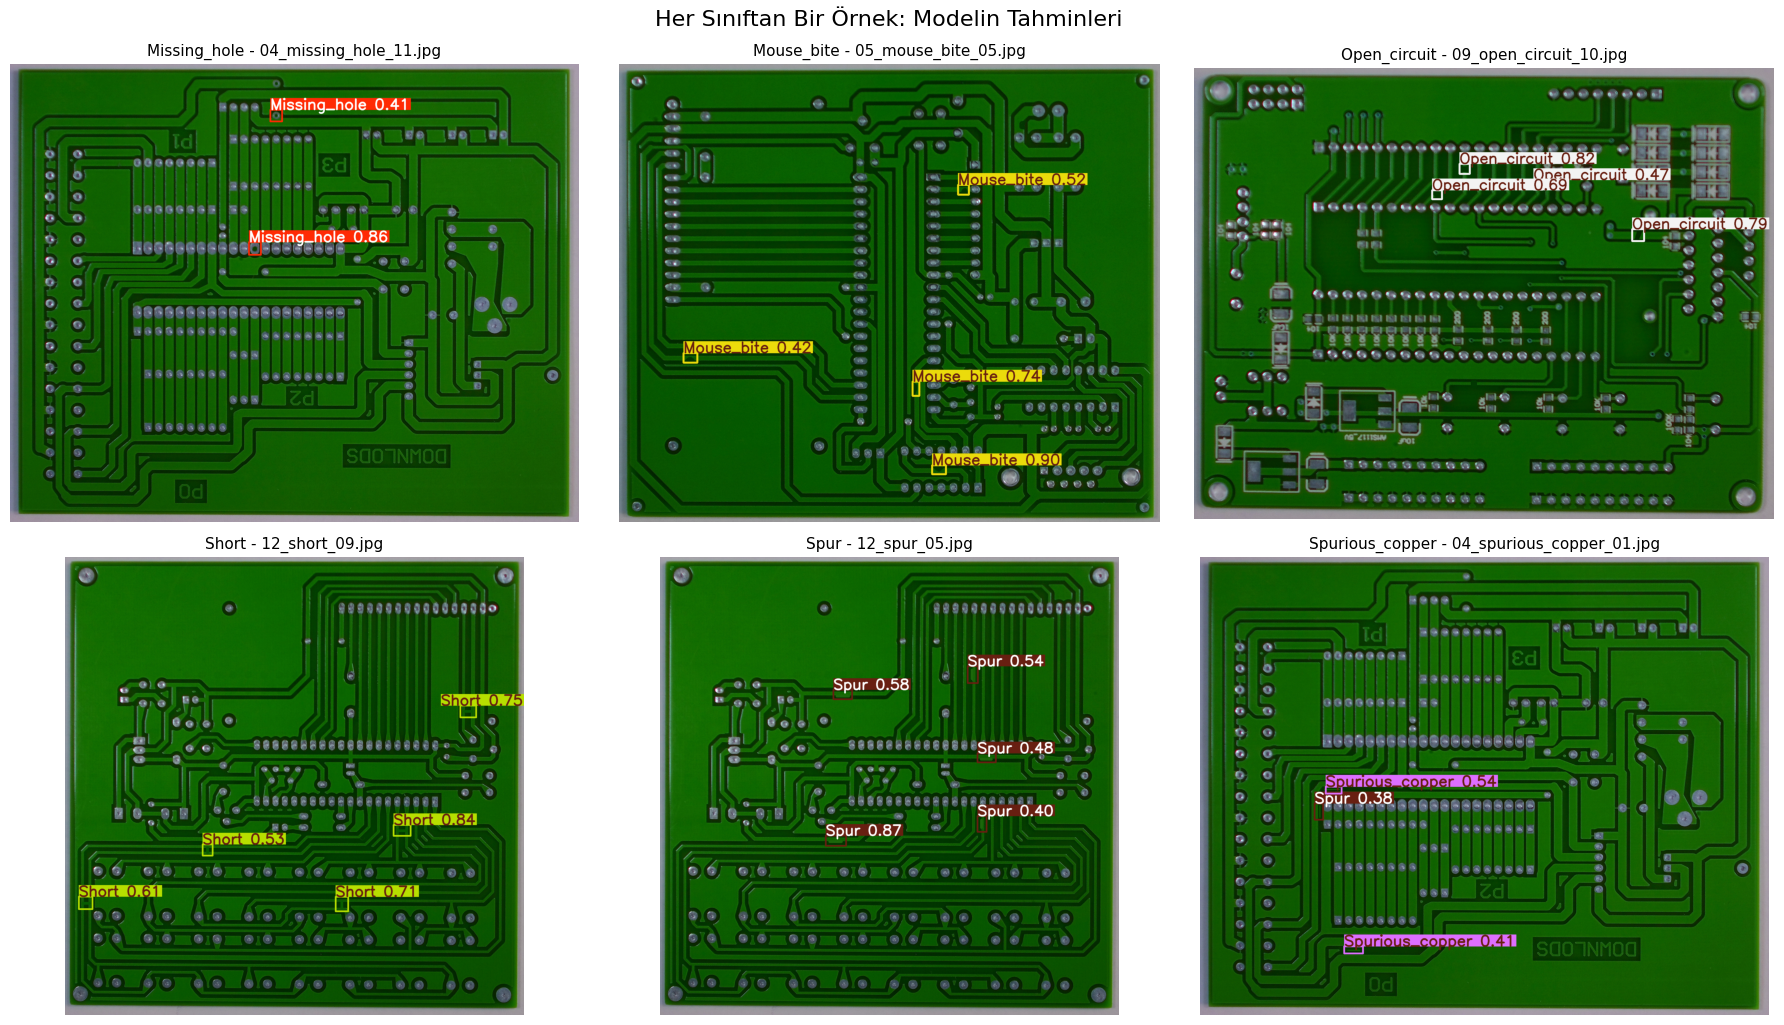

In [ ]:
# Sınıf-anahtar kelime eşleştirmesini düzeltelim (Spur ile Spurious_copper karışmasın)
class_list = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

test_images_folder = "dataset_yolo/images/test"
all_test_images = os.listdir(test_images_folder)

selected_images = []
random.seed(7)

for class_name in class_list:
    keyword = class_name.lower()
    if class_name == "Spur":
        # Sadece "spur_" ile başlayanları al, "spurious" olanları hariç tut
        matches = [f for f in all_test_images if "spur_" in f.lower() and "spurious" not in f.lower()]
    else:
        matches = [f for f in all_test_images if keyword in f.lower()]

    if matches:
        selected_images.append(random.choice(matches))
    else:
        print(f"UYARI: {class_name} için eşleşen dosya bulunamadı!")

# Görselleştir
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, img_name in enumerate(selected_images):
    img_path = os.path.join(test_images_folder, img_name)
    results = model(img_path, verbose=False)
    result_img = results[0].plot()

    axes[idx].imshow(result_img)
    axes[idx].set_title(f"{class_list[idx]} - {img_name}", fontsize=11)
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle("Her Sınıftan Bir Örnek: Modelin Tahminleri", fontsize=16, y=1.02)
plt.show()

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
from ultralytics import YOLO
import os
import random

model = YOLO("/content/runs/detect/pcb_training/ilk_deneme-2/weights/best.pt")

sınıf_türkçe = {
    "Missing_hole": "Eksik Delik",
    "Mouse_bite": "Fare Isırığı",
    "Open_circuit": "Açık Devre",
    "Short": "Kısa Devre",
    "Spur": "Çıkıntı / İğne Ucu",
    "Spurious_copper": "İstenmeyen Bakır Artığı"
}

def hata_tespit_et(görsel, güven_eşiği):
    if görsel is None:
        return None, "### 📋 Tespit Sonucu\nBir görsel yükleyip *'Hata Tespiti Yap'* butonuna basın, sonuçlar burada görünecek."

    results = model(görsel, conf=güven_eşiği, verbose=False)
    sonuç_görsel = results[0].plot()

    kutular = results[0].boxes
    if len(kutular) == 0:
        özet = "### ✅ Hata Tespit Edilmedi\nBu kartta belirlenen güven eşiğinin üzerinde bir hata bulunamadı."
    else:
        sayaç = {}
        toplam_güven = 0
        for kutu in kutular:
            sınıf_id = int(kutu.cls[0])
            sınıf_adı = model.names[sınıf_id]
            sayaç[sınıf_adı] = sayaç.get(sınıf_adı, 0) + 1
            toplam_güven += float(kutu.conf[0])

        ort_güven = (toplam_güven / len(kutular)) * 100
        özet = f"### ⚠️ Toplam {len(kutular)} Hata Tespit Edildi\n**Ortalama Güven Skoru:** %{ort_güven:.1f}\n\n"
        for sınıf_adı, adet in sayaç.items():
            tr_adı = sınıf_türkçe.get(sınıf_adı, sınıf_adı)
            özet += f"- **{tr_adı}**: {adet} adet\n"

    return sonuç_görsel, özet

test_klasör = "dataset_yolo/images/test"
örnek_yollar = []
random.seed(3)
if os.path.exists(test_klasör):
    tüm_dosyalar = os.listdir(test_klasör)
    seçilenler = random.sample(tüm_dosyalar, min(6, len(tüm_dosyalar)))
    örnek_yollar = [os.path.join(test_klasör, f) for f in seçilenler]

tema = gr.themes.Base(
    primary_hue="red",
    secondary_hue="red",
    neutral_hue="slate",
).set(
    button_primary_background_fill="#C8102E",
    button_primary_background_fill_hover="#A00D25",
    button_primary_text_color="white",
    block_title_text_color="#C8102E",
    block_label_text_color="#C8102E",
)

özel_css = """
.gradio-container {
    max-width: 1100px !important;
    margin: 0 auto !important;
}

span[data-testid="block-info"] {
    display: block !important;
    text-align: center !important;
    width: 100% !important;
    font-size: 14px !important;
    font-weight: 600 !important;
}
.ortali-baslik {
    text-align: center !important;
    font-size: 14px !important;
    font-weight: 600 !important;
}

#başlık-alani {
    background: linear-gradient(90deg, #C8102E 0%, #7A0A1D 100%);
    padding: 32px;
    border-radius: 14px;
    margin-bottom: 20px;
    text-align: center;
    box-shadow: 0 4px 16px rgba(200,16,46,0.25);
}
#başlık-alani h1 { color: white !important; margin-bottom: 6px !important; font-size: 32px !important; }
#başlık-alani p { color: #f5d5d9 !important; font-size: 16px !important; margin: 0 !important; }

/* Sağdaki (Tespit Sonucu) kutusuna, soldaki toolbar kadar boşluk ekle */
#cikis-goruntu-alan {
    padding-bottom: 42px;
    box-sizing: border-box;
}

#esik-kutu {
    background: #fafafa;
    border-radius: 10px;
    padding: 16px;
    border: 1px solid #eee;
    box-sizing: border-box;
    height: 140px;
    display: flex;
    flex-direction: column;
    justify-content: center;
}

#özet-kutusu {
    background: #fafafa;
    border-radius: 10px;
    padding: 16px;
    border: 1px solid #eee;
    text-align: center;
    box-sizing: border-box;
    height: 140px;
    display: flex;
    flex-direction: column;
    justify-content: center;
}

#galeri-sutunu, #metrik-sutunu {
    display: flex;
    flex-direction: column;
}
#ornek-galeri-kutu {
    height: 280px !important;
}
#metrik-bolumu {
    background: #fafafa;
    border-radius: 12px;
    padding: 16px;
    border: 1px solid #eee;
    height: 280px;
    box-sizing: border-box;
    display: flex;
    flex-direction: column;
    justify-content: center;
}
.metrik-grid-2x2 {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 10px;
}
.metrik-kart {
    background: white;
    border: 2px solid #C8102E;
    border-radius: 10px;
    padding: 12px 6px;
    text-align: center;
    box-shadow: 0 2px 6px rgba(0,0,0,0.06);
}
.metrik-kart .deger {
    color: #C8102E;
    font-size: 20px;
    font-weight: 700;
    white-space: nowrap;
}
.metrik-kart .etiket {
    color: #666;
    font-size: 11px;
    margin-top: 2px;
}

#hata-tipleri-bolumu { margin-top: 14px; }
#hata-tipleri-bolumu h4 {
    text-align: center;
    color: #333 !important;
    margin-bottom: 14px !important;
    font-size: 14px !important;
    font-weight: 600 !important;
}
.hata-tipi-grid {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 12px;
}
.hata-tipi-kart {
    background: white;
    border: 1px solid #e5c5ca;
    border-left: 4px solid #C8102E;
    border-radius: 8px;
    padding: 12px 14px;
    text-align: center;
    box-shadow: 0 1px 4px rgba(0,0,0,0.05);
}
.hata-tipi-kart .isim { color: #333; font-size: 13px; font-weight: 600; }

.alt-bilgi {
    text-align: center;
    color: #888 !important;
    font-size: 13px !important;
    margin-top: 20px !important;
}
"""

with gr.Blocks(title="Vestel AOI Sistemi") as demo:
    gr.HTML(
        """
        <div id="başlık-alani">
            <h1>🔴 VESTEL AOI SİSTEMİ</h1>
            <p>Otomatik Optik İnceleme — PCB Hata Tespiti | Yapay Zeka Destekli Kalite Kontrol</p>
        </div>
        """
    )

    with gr.Row():
        girdi_görsel = gr.Image(type="numpy", label="📷 PCB Kartı Fotoğrafı Yükleyin", height=420)
        çıktı_görsel = gr.Image(type="numpy", label="✅ Tespit Sonucu", height=420, elem_id="cikis-goruntu-alan")

    with gr.Row():
        with gr.Column(elem_id="esik-kutu"):
            güven_kaydırıcı = gr.Slider(
                minimum=0.1, maximum=0.9, value=0.25, step=0.05,
                label="🎚️ Güven Eşiği (Confidence Threshold)"
            )
        özet_kutu = gr.Markdown(
            "### 📋 Tespit Sonucu\nBir görsel yükleyip *'Hata Tespiti Yap'* butonuna basın, sonuçlar burada görünecek.",
            elem_id="özet-kutusu"
        )

    gönder_buton = gr.Button("Hata Tespiti Yap", variant="primary", size="lg")

    with gr.Row():
        with gr.Column(elem_id="galeri-sutunu"):
            gr.Markdown("**📁 Örnek PCB Görselleri (tıklayarak deneyebilirsiniz):**", elem_classes="ortali-baslik")
            örnek_galeri = gr.Gallery(
                value=örnek_yollar,
                columns=3,
                rows=2,
                height=280,
                show_label=False,
                object_fit="cover",
                elem_id="ornek-galeri-kutu"
            )
        with gr.Column(elem_id="metrik-sutunu"):
            gr.Markdown("**📊 Model Performans Özeti:**", elem_classes="ortali-baslik")
            gr.HTML(
                """
                <div id="metrik-bolumu">
                    <div class="metrik-grid-2x2">
                        <div class="metrik-kart"><div class="deger">%86.1</div><div class="etiket">mAP50</div></div>
                        <div class="metrik-kart"><div class="deger">%88.3</div><div class="etiket">Precision</div></div>
                        <div class="metrik-kart"><div class="deger">%81.8</div><div class="etiket">Recall</div></div>
                        <div class="metrik-kart"><div class="deger">~20 FPS</div><div class="etiket">İşlem Hızı (GPU)</div></div>
                    </div>
                </div>
                """
            )

    gr.HTML(
        """
        <div id="hata-tipleri-bolumu">
            <h4>🔎 Tespit Edilebilen Hata Tipleri</h4>
            <div class="hata-tipi-grid">
                <div class="hata-tipi-kart"><span class="isim">Eksik Delik</span></div>
                <div class="hata-tipi-kart"><span class="isim">Fare Isırığı</span></div>
                <div class="hata-tipi-kart"><span class="isim">Açık Devre</span></div>
                <div class="hata-tipi-kart"><span class="isim">Kısa Devre</span></div>
                <div class="hata-tipi-kart"><span class="isim">Çıkıntı / İğne Ucu</span></div>
                <div class="hata-tipi-kart"><span class="isim">İstenmeyen Bakır Artığı</span></div>
            </div>
        </div>
        """
    )

    gr.Markdown(
        "*Vestel Otomasyon Teknolojileri — Yazılım Birimi Staj Projesi | Model: YOLOv8n (Transfer Learning)*",
        elem_classes="alt-bilgi"
    )

    gönder_buton.click(fn=hata_tespit_et, inputs=[girdi_görsel, güven_kaydırıcı], outputs=[çıktı_görsel, özet_kutu])

    def galeriden_seç(evt: gr.SelectData):
        return örnek_yollar[evt.index]

    örnek_galeri.select(fn=galeriden_seç, outputs=girdi_görsel)

demo.launch(share=True, theme=tema, css=özel_css)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2a826d198f5b86dbb4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
# ============================================
# 🚀 HIZLI BAŞLANGIÇ — Eğitimi tekrarlamadan demo'yu açar
# Colab oturumu koptuğunda SADECE bu hücreyi çalıştırmanız yeterli
# (üstteki eğitim hücrelerine gerek yok, model zaten Drive'da hazır)
# ============================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q ultralytics gradio

import gradio as gr
from ultralytics import YOLO
import os
import random

model = YOLO("/content/drive/MyDrive/AOI_Vestel_Proje/best.pt")

sınıf_türkçe = {
    "Missing_hole": "Eksik Delik",
    "Mouse_bite": "Fare Isırığı",
    "Open_circuit": "Açık Devre",
    "Short": "Kısa Devre",
    "Spur": "Çıkıntı / İğne Ucu",
    "Spurious_copper": "İstenmeyen Bakır Artığı"
}

def hata_tespit_et(görsel, güven_eşiği):
    if görsel is None:
        return None, "### 📋 Tespit Sonucu\nBir görsel yükleyip *'Hata Tespiti Yap'* butonuna basın, sonuçlar burada görünecek."
    results = model(görsel, conf=güven_eşiği, verbose=False)
    sonuç_görsel = results[0].plot()
    kutular = results[0].boxes
    if len(kutular) == 0:
        özet = "### ✅ Hata Tespit Edilmedi\nBu kartta belirlenen güven eşiğinin üzerinde bir hata bulunamadı."
    else:
        sayaç = {}
        toplam_güven = 0
        for kutu in kutular:
            sınıf_adı = model.names[int(kutu.cls[0])]
            sayaç[sınıf_adı] = sayaç.get(sınıf_adı, 0) + 1
            toplam_güven += float(kutu.conf[0])
        ort_güven = (toplam_güven / len(kutular)) * 100
        özet = f"### ⚠️ Toplam {len(kutular)} Hata Tespit Edildi\n**Ortalama Güven Skoru:** %{ort_güven:.1f}\n\n"
        for sınıf_adı, adet in sayaç.items():
            özet += f"- **{sınıf_türkçe.get(sınıf_adı, sınıf_adı)}**: {adet} adet\n"
    return sonuç_görsel, özet

test_klasör = "dataset_yolo/images/test"
örnek_yollar = []
random.seed(3)
if os.path.exists(test_klasör):
    tüm_dosyalar = os.listdir(test_klasör)
    örnek_yollar = [os.path.join(test_klasör, f) for f in random.sample(tüm_dosyalar, min(6, len(tüm_dosyalar)))]

tema = gr.themes.Base(primary_hue="red", secondary_hue="red", neutral_hue="slate").set(
    button_primary_background_fill="#C8102E",
    button_primary_background_fill_hover="#A00D25",
    button_primary_text_color="white",
    block_title_text_color="#C8102E",
    block_label_text_color="#C8102E",
)

özel_css = """
.gradio-container { max-width: 1100px !important; margin: 0 auto !important; }
span[data-testid="block-info"] { display: block !important; text-align: center !important; width: 100% !important; font-size: 14px !important; font-weight: 600 !important; }
.ortali-baslik { text-align: center !important; font-size: 14px !important; font-weight: 600 !important; }
#başlık-alani {
    background: linear-gradient(90deg, #C8102E 0%, #7A0A1D 100%);
    padding: 32px; border-radius: 14px; margin-bottom: 20px; text-align: center;
    box-shadow: 0 4px 16px rgba(200,16,46,0.25);
}
#başlık-alani h1 { color: white !important; margin-bottom: 6px !important; font-size: 32px !important; }
#başlık-alani p { color: #f5d5d9 !important; font-size: 16px !important; margin: 0 !important; }
#cikis-goruntu-alan { padding-bottom: 42px; box-sizing: border-box; }
#esik-kutu {
    background: #fafafa; border-radius: 10px; padding: 16px; border: 1px solid #eee;
    box-sizing: border-box; height: 140px; display: flex; flex-direction: column; justify-content: center;
}
#özet-kutusu {
    background: #fafafa; border-radius: 10px; padding: 16px; border: 1px solid #eee;
    text-align: center; box-sizing: border-box; height: 140px; display: flex; flex-direction: column; justify-content: center;
}
#galeri-sutunu, #metrik-sutunu { display: flex; flex-direction: column; }
#ornek-galeri-kutu { height: 280px !important; }
#metrik-bolumu {
    background: #fafafa; border-radius: 12px; padding: 16px; border: 1px solid #eee;
    height: 280px; box-sizing: border-box; display: flex; flex-direction: column; justify-content: center;
}
.metrik-grid-2x2 { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; }
.metrik-kart {
    background: white; border: 2px solid #C8102E; border-radius: 10px; padding: 12px 6px;
    text-align: center; box-shadow: 0 2px 6px rgba(0,0,0,0.06);
}
.metrik-kart .deger { color: #C8102E; font-size: 20px; font-weight: 700; white-space: nowrap; }
.metrik-kart .etiket { color: #666; font-size: 11px; margin-top: 2px; }
#hata-tipleri-bolumu { margin-top: 14px; }
#hata-tipleri-bolumu h4 { text-align: center; color: #333 !important; margin-bottom: 14px !important; font-size: 14px !important; font-weight: 600 !important; }
.hata-tipi-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; }
.hata-tipi-kart {
    background: white; border: 1px solid #e5c5ca; border-left: 4px solid #C8102E; border-radius: 8px;
    padding: 12px 14px; text-align: center; box-shadow: 0 1px 4px rgba(0,0,0,0.05);
}
.hata-tipi-kart .isim { color: #333; font-size: 13px; font-weight: 600; }
.alt-bilgi { text-align: center; color: #888 !important; font-size: 13px !important; margin-top: 20px !important; }
"""

with gr.Blocks(title="Vestel AOI Sistemi") as demo:
    gr.HTML('<div id="başlık-alani"><h1>🔴 VESTEL AOI SİSTEMİ</h1><p>Otomatik Optik İnceleme — PCB Hata Tespiti | Yapay Zeka Destekli Kalite Kontrol</p></div>')

    with gr.Row():
        girdi_görsel = gr.Image(type="numpy", label="📷 PCB Kartı Fotoğrafı Yükleyin", height=420)
        çıktı_görsel = gr.Image(type="numpy", label="✅ Tespit Sonucu", height=420, elem_id="cikis-goruntu-alan")

    with gr.Row():
        with gr.Column(elem_id="esik-kutu"):
            güven_kaydırıcı = gr.Slider(minimum=0.1, maximum=0.9, value=0.25, step=0.05, label="🎚️ Güven Eşiği (Confidence Threshold)")
        özet_kutu = gr.Markdown(
            "### 📋 Tespit Sonucu\nBir görsel yükleyip *'Hata Tespiti Yap'* butonuna basın, sonuçlar burada görünecek.",
            elem_id="özet-kutusu"
        )

    gönder_buton = gr.Button("Hata Tespiti Yap", variant="primary", size="lg")

    with gr.Row():
        with gr.Column(elem_id="galeri-sutunu"):
            gr.Markdown("**📁 Örnek PCB Görselleri (tıklayarak deneyebilirsiniz):**", elem_classes="ortali-baslik")
            örnek_galeri = gr.Gallery(
                value=örnek_yollar, columns=3, rows=2, height=280,
                show_label=False, object_fit="cover", elem_id="ornek-galeri-kutu"
            )
        with gr.Column(elem_id="metrik-sutunu"):
            gr.Markdown("**📊 Model Performans Özeti:**", elem_classes="ortali-baslik")
            gr.HTML("""
                <div id="metrik-bolumu">
                    <div class="metrik-grid-2x2">
                        <div class="metrik-kart"><div class="deger">%86.1</div><div class="etiket">mAP50</div></div>
                        <div class="metrik-kart"><div class="deger">%88.3</div><div class="etiket">Precision</div></div>
                        <div class="metrik-kart"><div class="deger">%81.8</div><div class="etiket">Recall</div></div>
                        <div class="metrik-kart"><div class="deger">~20 FPS</div><div class="etiket">İşlem Hızı (GPU)</div></div>
                    </div>
                </div>
            """)

    gr.HTML("""
        <div id="hata-tipleri-bolumu">
            <h4>🔎 Tespit Edilebilen Hata Tipleri</h4>
            <div class="hata-tipi-grid">
                <div class="hata-tipi-kart"><span class="isim">Eksik Delik</span></div>
                <div class="hata-tipi-kart"><span class="isim">Fare Isırığı</span></div>
                <div class="hata-tipi-kart"><span class="isim">Açık Devre</span></div>
                <div class="hata-tipi-kart"><span class="isim">Kısa Devre</span></div>
                <div class="hata-tipi-kart"><span class="isim">Çıkıntı / İğne Ucu</span></div>
                <div class="hata-tipi-kart"><span class="isim">İstenmeyen Bakır Artığı</span></div>
            </div>
        </div>
    """)

    gr.Markdown("*Vestel Otomasyon Teknolojileri — Yazılım Birimi Staj Projesi | Model: YOLOv8n (Transfer Learning)*", elem_classes="alt-bilgi")

    gönder_buton.click(fn=hata_tespit_et, inputs=[girdi_görsel, güven_kaydırıcı], outputs=[çıktı_görsel, özet_kutu])

    def galeriden_seç(evt: gr.SelectData):
        return örnek_yollar[evt.index]

    örnek_galeri.select(fn=galeriden_seç, outputs=girdi_görsel)

demo.launch(share=True, theme=tema, css=özel_css)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 6.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://52a3ba9db4d34259c3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
